In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load cleaned csv

In [2]:
df = pd.read_csv('../data/housing_clean.csv')

## Define features & target

In [3]:
X = df.drop(columns=['price_per_unit'])
y = df['price_per_unit']

## Train test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 321 rows | Test: 81 rows


Recall that we split the data so the model is evaluated on rows it has never seen during training. The 80/20 split gives us 321 rows to train on and 81 to test on. random_state=42 makes the split reproducible and so every time I run this notebook I get the same rows in each set. Note that with only 81 test rows, a single unusual property can meaningfully shift our metrics. More data is always better

## Scale our data

In [5]:
continuous_features = ['mrt_distance_log', 'house_age_log', 'latitude']
dummy_features = ['convenience_bins_low', 'convenience_bins_medium', 'convenience_bins_high']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit only on training data — then transform separately
scaler.fit(X_train[continuous_features])

X_train_scaled[continuous_features] = scaler.transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

X_train_scaled.head()

,latitude,mrt_distance_log,house_age_log,convenience_bins_low,convenience_bins_medium,convenience_bins_high
18,-0.173588,-0.351811,0.290456,False,False,True
203,0.818876,-0.299244,-0.855555,False,True,False
351,-0.323252,-0.923016,-2.025735,False,True,False
275,-1.536451,0.870030,-1.640210,True,False,False
63,-0.323252,-0.923016,-2.078471,False,True,False


We scale only the three continuous features `mrt_distance_log`, `house_age_log`, and `latitude`. 

The dummy variables are left as 0/1 because scaling them would distort their meaning as category membership flags.
The scaling happens in two explicit steps. 
- First, scaler.fit() is called on the training data only as this computes the mean and standard deviation for each continuous feature. 
- Then scaler.transform() is called separately on both train and test using those same stored parameters.

The critical rule: we never call fit on the test data. If we did, the scaler would compute new means and standard deviations from the test set, which means the test data would be transformed on its own terms rather than the training data's terms which would make the comparison between train and test invalid. More importantly, fitting on the full dataset before splitting would leak test set information into the scaling parameters, giving us an unrealistically optimistic evaluation. Recall that this is called data leakage and it's one of the most common mistakes in machine learning pipelines.

## Build our models

In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression metrics")
print(f"  R²:   {r2_score(y_test, y_pred_lr):.4f}")
print(f"  MSE: {(mean_squared_error(y_test, y_pred_lr)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.4f}")

Linear Regression metrics
  R²:   0.6169
  MSE: 54.5489
  RMSE: 7.3857


R² of 0.6169 means the model explains ~ 62% of the variance in house prices. For a real-world dataset with only 6 features this is a reasonable baseline — the remaining 38% is likely driven by things we simply don't have in our data. 

**Does anyone have ideas of additional features that could be included in our dataset which could improve our R²?**. 

RMSE of 7.39 means predictions are off by roughly 7.4 price units on average. To ground that number: the target ranges from ~8 to ~117 with a mean of ~38, so we're looking at roughly a 19% error on a typical property.

In [7]:
ridge = Ridge(alpha=0.1) # < ---- try different alphas here, recall that this is our lambda in regrularization
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("RIDGE REGRESSION (alpha=0.1)")
print(f"  R²:   {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  MSE: {(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

RIDGE REGRESSION (alpha=0.1)
  R²:   0.6171
  MSE: 54.5136
  RMSE: 7.3833


Ridge adds an L2 penalty to the loss function and it discourages large coefficients by adding the sum of squared coefficients to what the model is minimising. **The alpha parameter controls how strong that penalty is, and is equivalent to lambda (λ) in the regularization formula.** Higher alpha = more shrinkage. 

Crucially, Ridge shrinks coefficients toward zero but never exactly to zero. It reduces their size but keeps all features in the model. The R² of 0.6171 is virtually unchanged from plain linear regression, which is expected: 
- Ridge helps most when there's severe multicollinearity or many features. After our feature engineering and dropping of collinear columns, there isn't much for Ridge to fix.

In [8]:
lasso = Lasso(alpha=0.5) 
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("LASSO REGRESSION (alpha=0.5)")
print(f"  R²:   {r2_score(y_test, y_pred_lasso):.4f}")
print(f"  MSE: {(mean_squared_error(y_test, y_pred_lasso)):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")

LASSO REGRESSION (alpha=0.5)
  R²:   0.6459
  MSE: 50.4229
  RMSE: 7.1009


Lasso adds an L1 penalty which is the sum of absolute coefficients rather than squared. This seemingly small difference has a big practical consequence: 

**Lasso can shrink coefficients all the way to exactly zero, effectively removing features from the model entirely.** 

This makes Lasso a tool for both regularisation and automatic feature selection simultaneously. R² of 0.6459 is a meaningful improvement over both linear regression and Ridge. Lasso is outperforming because it's eliminating noisy features rather than just shrinking them. The optimal alpha is not directly comparable between Ridge and Lasso since they operate on different penalty scales — choosing it properly is where cross-validation comes in, which we will visit next phase.

In [15]:
lasso_coefs = pd.Series(lasso.coef_, index=X_train.columns)
lasso_coefs

latitude                   3.913805
mrt_distance_log          -7.351144
house_age_log             -2.689539
convenience_bins_low      -0.007741
convenience_bins_medium    0.000000
convenience_bins_high      0.000000
dtype: float64

Lasso's feature selection property made visible. `convenience_bins_medium` and `convenience_bins_high` have been zeroed out completely. Lasso decided these features contribute insufficient signal and removed them. `convenience_bins_low` survived but barely, with a coefficient of -0.008. The three retained features tell a clean story that maps directly back to the EDA: `mrt_distance_log` at -7.35 is the dominant predictor by a wide margin, `latitude` at 3.91 confirms the north-south price gradient we saw on the geographic map, and `house_age_log` at -2.69 confirms older properties are cheaper. The sign tells us direction, the magnitude tells us importance, but only because we standardised the continuous features before fitting. Without scaling this comparison would be meaningless.

Ideally we would use Ridge_CV and Lasso_CV to determine the best alpha for the respective models.

## Overfitting diagnostic

In [10]:
print("Train R²:")
print(f"  Linear Regression: {r2_score(y_train, lr.predict(X_train_scaled)):.4f}")
print(f"  Ridge:             {r2_score(y_train, ridge.predict(X_train_scaled)):.4f}")
print(f"  Lasso:             {r2_score(y_train, lasso.predict(X_train_scaled)):.4f}")

print("\nTest R²:")
print(f"  Linear Regression: {r2_score(y_test, y_pred_lr):.4f}")
print(f"  Ridge:             {r2_score(y_test, y_pred_ridge):.4f}")
print(f"  Lasso:             {r2_score(y_test, y_pred_lasso):.4f}")

Train R²:
  Linear Regression: 0.6497
  Ridge:             0.6497
  Lasso:             0.6309

Test R²:
  Linear Regression: 0.6169
  Ridge:             0.6171
  Lasso:             0.6459


We're looking for a large gap between train and test R² as a sign that the model has memorised the training data rather than learned generalizable patterns. The gaps here are small across all three models (~0.02–0.03), so there's no overfitting concern. 

The Lasso result is the most instructive: it has the lowest train R² of the three (0.6309) but the highest test R² (0.6459). This is regularization doing exactly what it's supposed to; intentionally giving up a small amount of training performance in exchange for better generalization to new data. This is a direct illustration of the bias-variance tradeoff that we discussed in lecture.

We will explore additional and more robust ways to diagnose overfitting once we discuss cross validation

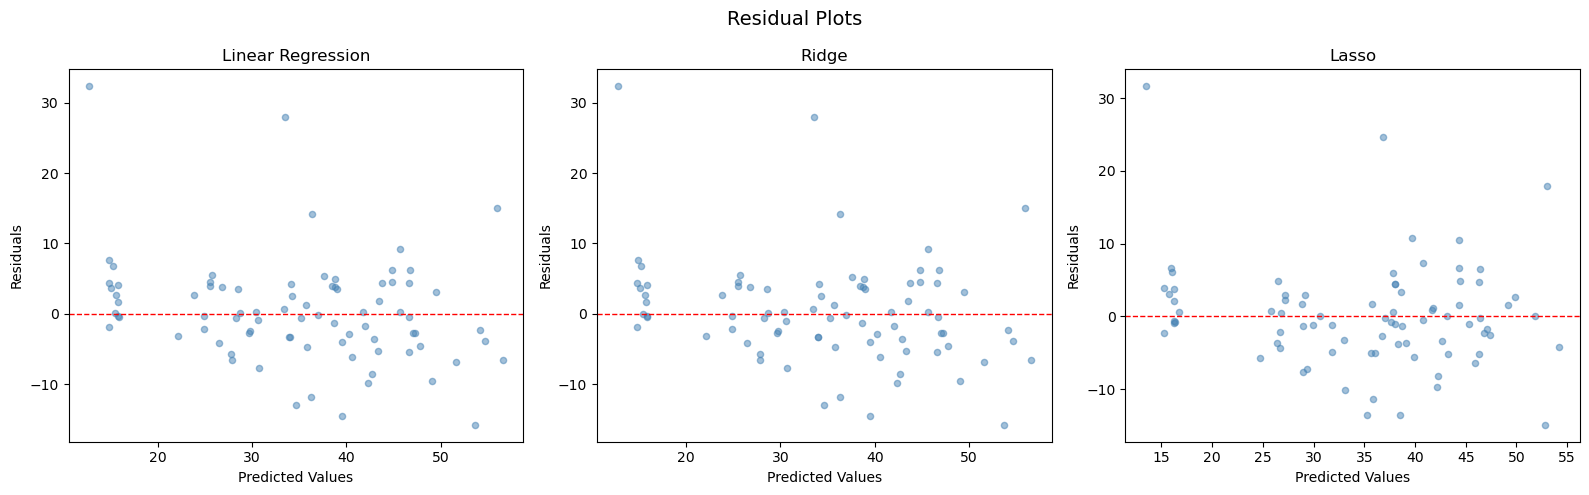

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = {
    'Linear Regression': y_pred_lr,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso
}

for ax, (name, y_pred) in zip(axes, models.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, color='steelblue', s=20)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals')
    ax.set_title(name)

plt.suptitle('Residual Plots', fontsize=14)
plt.tight_layout()
plt.show()

The residual plots look broadly healthy across all three models. Residuals are scattered on both sides of the zero line with no strong curve or arc, which means the linearity assumption is reasonably satisfied.

A few things worth pointing out however. There is a mild funnel shape visible, as residuals appear slightly more spread out in the 25–40 predicted value range than at the extremes. This is a soft sign of heteroscedasticity, meaning the model's errors are not perfectly consistent across the range of predictions. It's not severe enough to invalidate the model but it's worth acknowledging.

The cluster of large positive residuals at low predicted values (15–20 range) across all three models indicates the model is systematically underestimating some cheaper properties. This could be properties that are priced higher than their features would suggest; perhaps due to factors not captured in the dataset.

Overall the residuals are centred around zero without a systematic bias, which is what matters most. The model is not consistently over or under predicting across the board its errors are relatively random, which is the core assumption we need to hold.

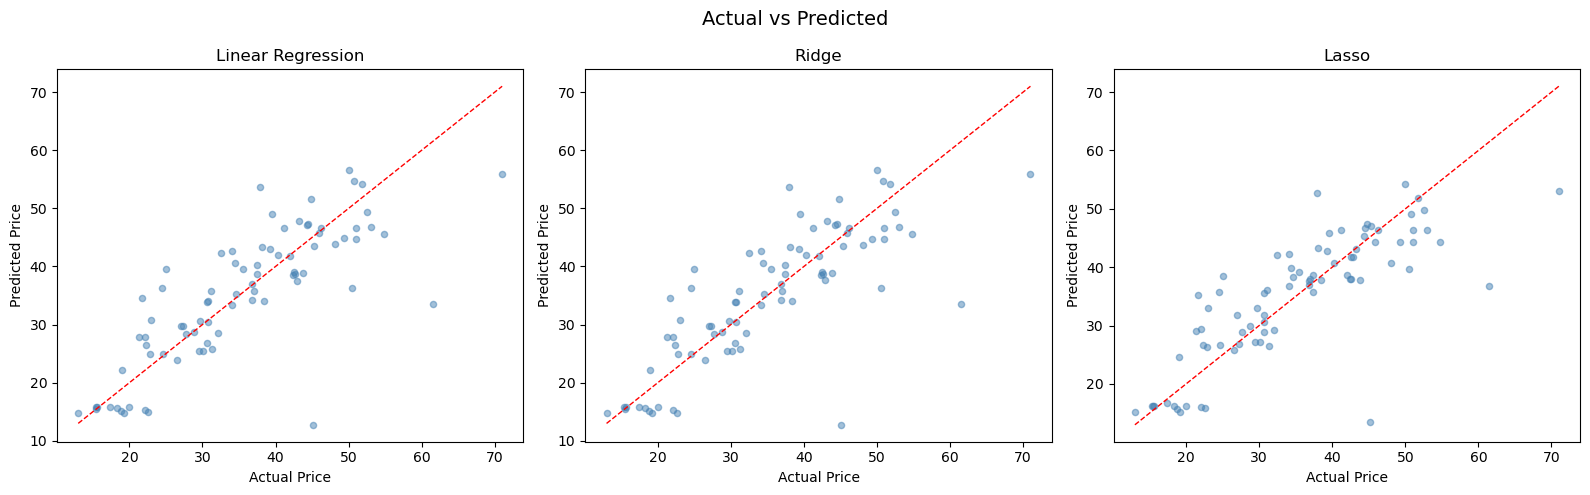

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred) in zip(axes, models.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)

plt.suptitle('Actual vs Predicted', fontsize=14)
plt.tight_layout()
plt.show()

The overall picture is encouraging as there's a clear positive trend following the diagonal across all three models, confirming the models have genuinely learned the relationship between features and price.

The low end (actual prices 15–25) is predicted well, with points hugging the diagonal tightly. The mid-range (25–45) shows the most scatter on both sides, which is expected given it's the densest and most varied region of the dataset.

The most interesting story is at the high end. The two outlier properties with actual prices around 60–70 are significantly underestimated by all three models, with predictions sitting around 45–55. These are the luxury properties flagged during EDA and there simply aren't enough of them in the training data for the model to learn what drives their prices, so it pulls predictions toward the middle. This is a dataset limitation, not a modeling flaw.

Lasso is visually the tightest of the three, consistent with its superior R². Linear Regression and Ridge are nearly indistinguishable, again matching the metrics table exactly.

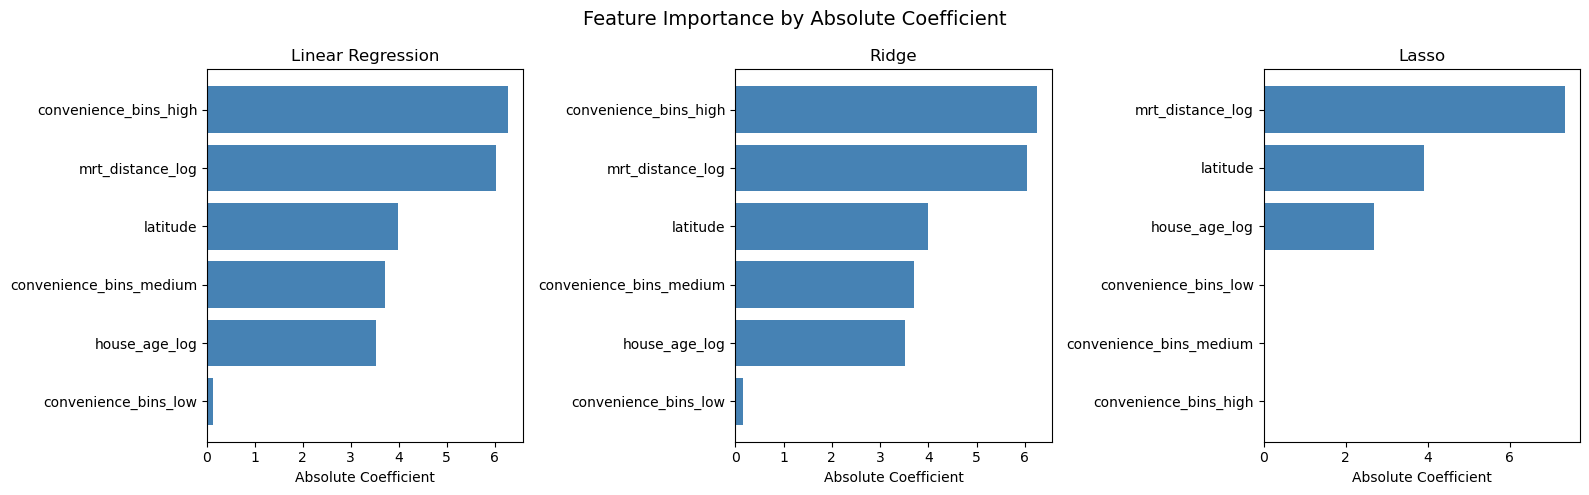

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

coef_data = {
    'Linear Regression': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
}

for ax, (name, coefs) in zip(axes, coef_data.items()):
    abs_coefs = pd.Series(np.abs(coefs), index=X_train.columns).sort_values(ascending=True)
    ax.barh(abs_coefs.index, abs_coefs.values, color='steelblue')
    ax.set_xlabel('Absolute Coefficient')
    ax.set_title(name)

plt.suptitle('Feature Importance by Absolute Coefficient', fontsize=14)
plt.tight_layout()
plt.show()

The Lasso chart tells the clearest story where `mrt_distance_log` is the dominant feature by a significant margin, `latitude` second, `house_age_log` third, and the three convenience bin dummies are effectively zero. This is clean, interpretable, and maps directly back to what the correlation heatmap showed during EDA.

Linear Regression and Ridge tell a more complicated story. `convenience_bins_high` is ranking as the top feature in both, which is a red flag as it's almost certainly a consequence of the dummy encoding interacting with the scale of the other features rather than a genuine signal. This is exactly the limitation mentioned earlier: absolute coefficients are only fully comparable across features of the same type. Comparing a scaled continuous feature against a 0/1 dummy is still somewhat apples to oranges, so treat the ranking of dummies against continuous features with caution.

The practical takeaway is that Lasso has done the interpretation work for us. By zeroing out the noise it's left behind only the features that genuinely matter, producing a result that is both more accurate and easier to explain.

## Notebook Summary

The model performs reasonably well for its complexity. With only 6 features and a dataset of ~400 properties, a test R² of 0.65 from Lasso is a solid result. The features we engineered during wrangling are doing real work.

Lasso is the clear winner across all three metrics. More importantly, the reason it wins is instructive — it didn't find new signal, it removed noise. By zeroing out the convenience bin dummies it simplified the model, and that simplification improved generalization. Ridge barely moved from the linear regression baseline, which tells us that after the wrangling decisions we made, dropping `longitude`, removing the erroneous `house age`, log-transforming `MRT distance`, the remaining feature set was already relatively clean.

The residual and actual vs predicted plots confirm the model is well-behaved in the mid-price range where most of the data lives, but consistently struggles with luxury properties at the high end. That's not a failure of the modeling approach but rather a reflection of what's in the data. Better performance there would require either more observations in that price range or additional features that capture what drives luxury pricing.

The broader lesson the notebook demonstrates is that the quality of the final model is largely determined before you ever call .fit(). The log transformation of MRT distance, the removal of the 410-year outlier, the decision to drop longitude. Each of those wrangling steps has a traceable impact on the output. That connection between data preparation and model performance is the central skill this phase of the course is building toward.